# Phase 4: Trajectory & RAI-Resistance
Order thyrocytes along a diffusion pseudotime from Paratumor to RAI-Refractory metastasis, track loss of thyroid differentiation (the basis of radioiodine uptake), and extract genes driving RAI resistance.

### Cell 1: Imports & Load Thyrocytes

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ad.settings.allow_write_nullable_strings = True  # needed to save .h5ad with pandas 2.x
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=80, facecolor="white")

PROCESSED_DIR = os.path.join(os.getcwd(), "processed_data")
STAGES = ["Paratumor", "Primary Tumor", "LN Metastasis", "RAI-Refractory Metastasis"]

adata_thy = sc.read_h5ad(os.path.join(PROCESSED_DIR, "adata_thyrocytes.h5ad"))
print(adata_thy)

AnnData object with n_obs × n_vars = 49419 × 26825
    obs: 'sample_id', 'gsm_id', 'patient_id', 'tissue_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'score_Thyrocytes', 'score_T-cells', 'score_NK cells', 'score_B cells', 'score_Plasma cells', 'score_Myeloid', 'score_Mast cells', 'score_Fibroblasts', 'score_Endothelial', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'patient_id_colors', 'pca', 'tissue_type_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'
    layers: None (.X)


### Cell 2: Thyrocyte-Specific Graph & Diffusion Pseudotime
The neighbour graph is rebuilt on thyrocytes only. The root is the Paratumor cell at the extreme of the first diffusion component, on the side opposite the RAI-Refractory cells.

computing neighbors


    finished (0:01:22)


computing UMAP


    finished (0:00:41)


computing Diffusion Maps using n_comps=15(=n_dcs)


...

    eigenvalues of transition matrix
    [1.         0.9938335  0.9822998  0.96824926 0.9622631  0.9582843
     0.9540037  0.950644   0.94900936 0.94697493 0.94409066 0.94177026
     0.9387916  0.93506485 0.93021494]


    finished (0:00:02)


computing Diffusion Pseudotime using n_dcs=10


    finished (0:00:00)


Cells unreachable from root: 0

Mean pseudotime per stage:
tissue_type
Paratumor                    0.257582
Primary Tumor                0.732083
LN Metastasis                0.727939
RAI-Refractory Metastasis    0.744188
Name: dpt_pseudotime, dtype: float32


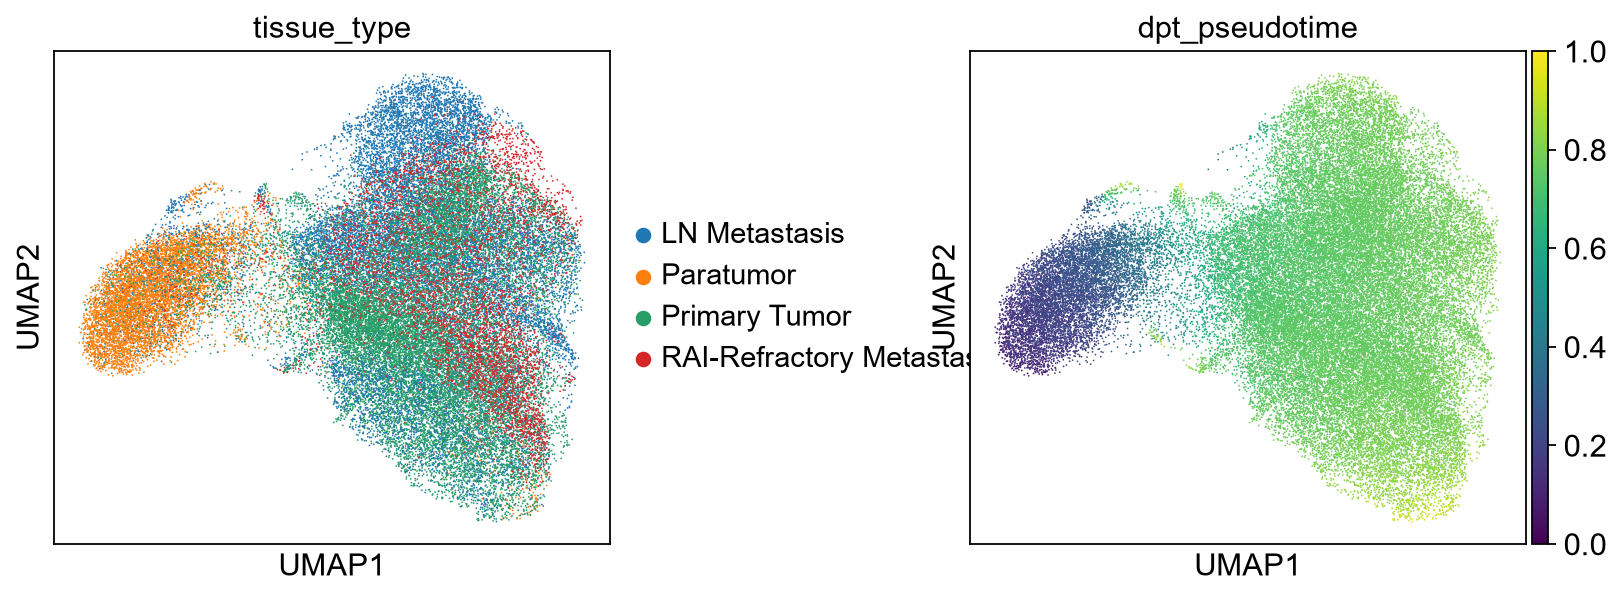

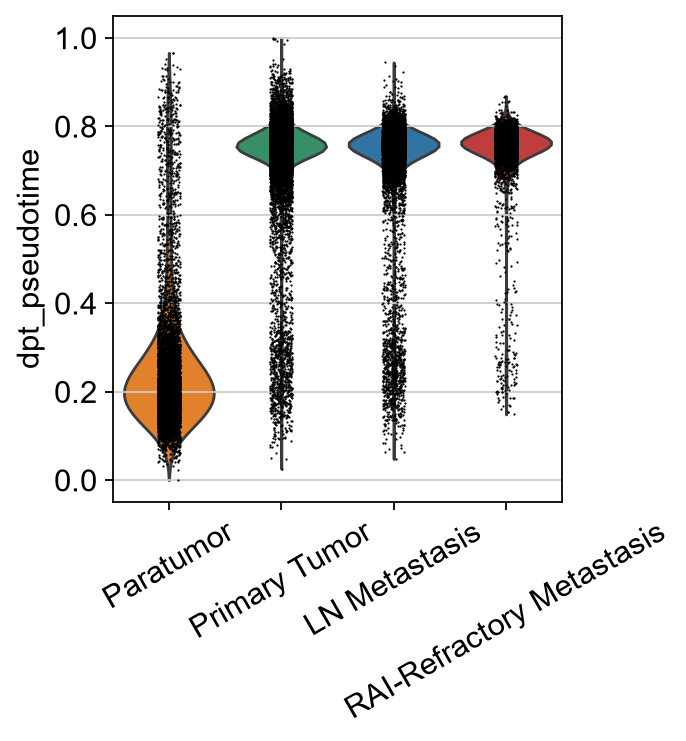

In [2]:
sc.pp.neighbors(adata_thy, n_neighbors=15, n_pcs=30, use_rep="X_pca_harmony")
sc.tl.umap(adata_thy)
sc.tl.diffmap(adata_thy, n_comps=15)

dc1 = adata_thy.obsm["X_diffmap"][:, 1]
is_para = (adata_thy.obs["tissue_type"] == "Paratumor").values
is_rai = (adata_thy.obs["tissue_type"] == "RAI-Refractory Metastasis").values
direction = np.sign(dc1[is_rai].mean() - dc1[is_para].mean())
para_idx = np.flatnonzero(is_para)
adata_thy.uns["iroot"] = int(para_idx[np.argmin(direction * dc1[para_idx])])

sc.tl.dpt(adata_thy)
pt = adata_thy.obs["dpt_pseudotime"].replace([np.inf, -np.inf], np.nan)
print("Cells unreachable from root:", int(pt.isna().sum()))
print("\nMean pseudotime per stage:")
print(pt.groupby(adata_thy.obs["tissue_type"], observed=True).mean().reindex(STAGES))

sc.pl.umap(adata_thy, color=["tissue_type", "dpt_pseudotime"], wspace=0.5)
sc.pl.violin(adata_thy, "dpt_pseudotime", groupby="tissue_type", order=STAGES, rotation=30)

### Cell 3: Thyroid Differentiation Score (RAI-Avidity Genes)
Radioiodine therapy depends on iodide-handling genes (e.g. `SLC5A5`/NIS, `TPO`, `TG`). Their loss along the trajectory explains RAI refractoriness, and these genes are the targets of redifferentiation (therapy-reversal) strategies.

computing score 'TDS_score'


    finished (0:00:00)


TDS genes used: ['TG', 'TPO', 'SLC5A5', 'SLC26A4', 'TSHR', 'PAX8', 'FOXE1', 'NKX2-1', 'DIO1', 'DIO2', 'DUOX1', 'DUOX2', 'SLC5A8', 'GLIS3', 'TFF3']
tissue_type
Paratumor                    1.106718
Primary Tumor                0.207115
LN Metastasis                0.135020
RAI-Refractory Metastasis   -0.084048
Name: TDS_score, dtype: float64


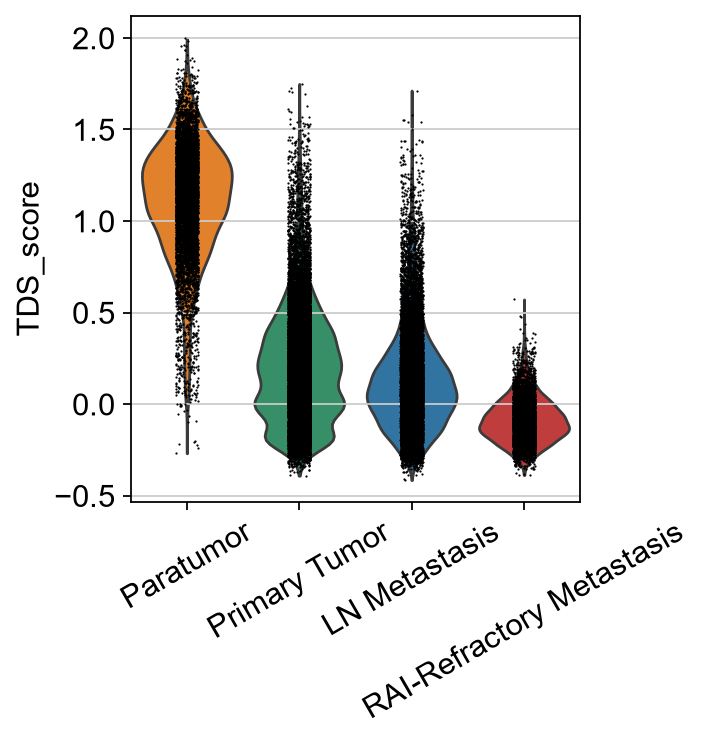

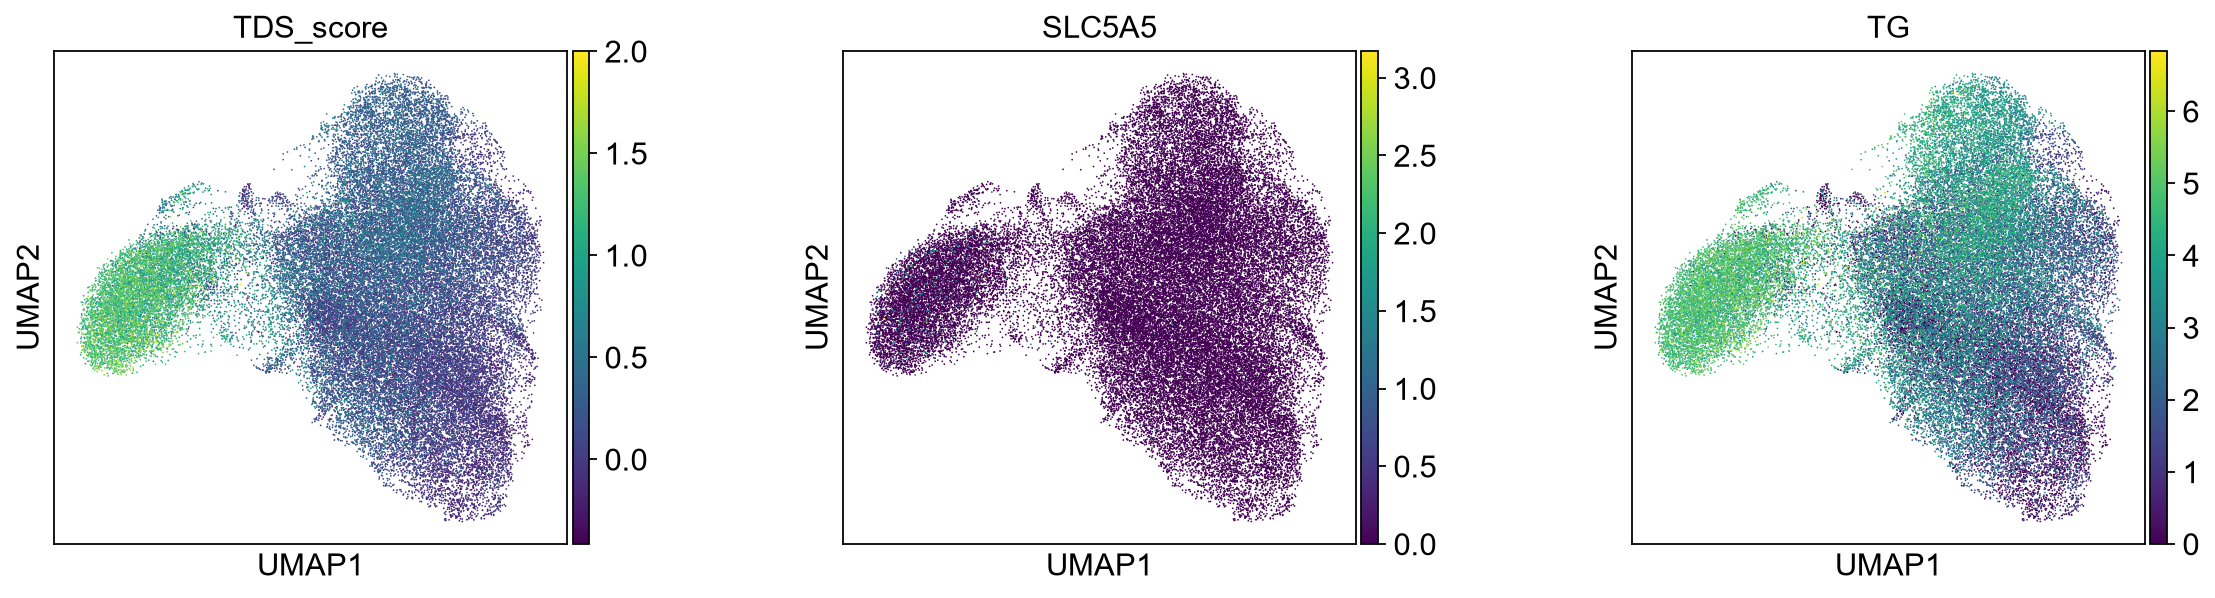

In [3]:
tds_genes = [g for g in ["TG", "TPO", "SLC5A5", "SLC26A4", "TSHR", "PAX8", "FOXE1", "NKX2-1",
                          "DIO1", "DIO2", "DUOX1", "DUOX2", "SLC5A8", "GLIS3", "TFF3"] if g in adata_thy.var_names]
sc.tl.score_genes(adata_thy, gene_list=tds_genes, score_name="TDS_score", use_raw=False)
print("TDS genes used:", tds_genes)
print(adata_thy.obs.groupby("tissue_type", observed=True)["TDS_score"].mean().reindex(STAGES))

sc.pl.violin(adata_thy, "TDS_score", groupby="tissue_type", order=STAGES, rotation=30)
sc.pl.umap(adata_thy, color=["TDS_score", "SLC5A5", "TG"], use_raw=False, wspace=0.4)

### Cell 4: Differential Expression — RAI-Refractory vs Paratumor
**Caveat:** the RAI-Refractory group comes from only 2 patients (PTC4, PTC11), so cell-level p-values are optimistic; treat genes as candidates for validation (Phase 6).

ranking genes


    finished (0:03:10)


Up-regulated: 1992 genes | Down-regulated: 1562 genes

Top 20 genes UP in RAI-Refractory metastasis:
     names    scores  logfoldchanges  pvals  pvals_adj
    S100A4 94.137657        8.029782    0.0        0.0
    LGALS3 92.352173        5.598606    0.0        0.0
    S100A1 91.335060        4.708271    0.0        0.0
       FN1 90.683052        7.040617    0.0        0.0
    S100A6 89.988289        2.691129    0.0        0.0
    TMSB10 87.804207        2.831471    0.0        0.0
     TIMP1 86.777435        4.790832    0.0        0.0
    TMSB4X 86.192612        4.482646    0.0        0.0
   S100A10 85.829582        4.960901    0.0        0.0
     RPL28 85.167580        1.456818    0.0        0.0
      FTH1 84.697395        1.745494    0.0        0.0
   S100A11 83.955887        2.724929    0.0        0.0
     HSPB1 83.875984        3.309671    0.0        0.0
    IGFBP6 82.546173        6.530838    0.0        0.0
  SERPINA1 82.062920        4.801755    0.0        0.0
AC090498.1 80.47502

    using 'X_pca' with n_pcs = 50


Storing dendrogram info using `.uns['dendrogram_tissue_type']`


categories: LN Metastasis, Paratumor, Primary Tumor, etc.
var_group_labels: RAI-Refractory Metastasis


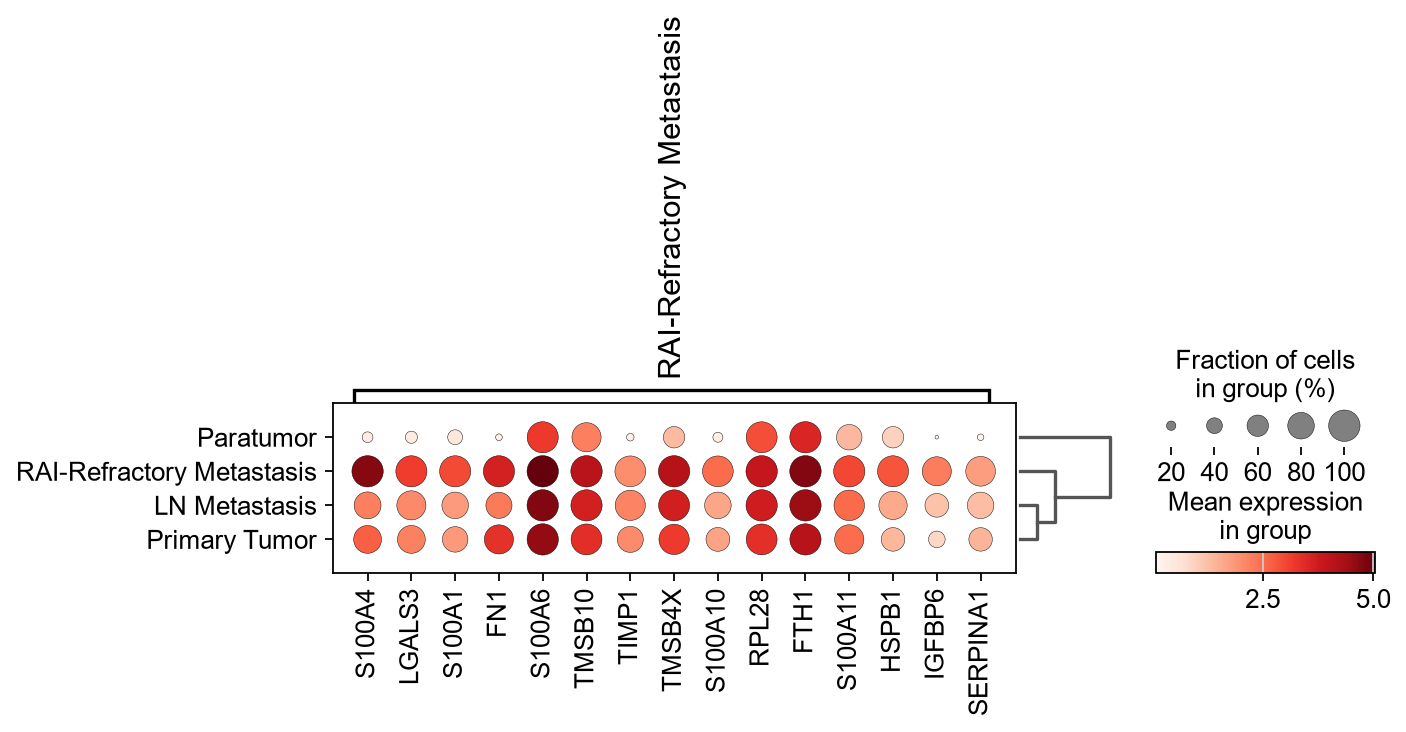

In [4]:
# use_raw=False: test on log-normalised X, not raw counts
sc.tl.rank_genes_groups(adata_thy, groupby="tissue_type", reference="Paratumor",
                        method="wilcoxon", use_raw=False)
deg_df = sc.get.rank_genes_groups_df(adata_thy, group="RAI-Refractory Metastasis")
deg_df.to_csv(os.path.join(PROCESSED_DIR, "deg_RAI_vs_Paratumor.csv"), index=False)

up = deg_df[(deg_df["logfoldchanges"] > 1.0) & (deg_df["pvals_adj"] < 0.05)].sort_values("scores", ascending=False)
down = deg_df[(deg_df["logfoldchanges"] < -1.0) & (deg_df["pvals_adj"] < 0.05)].sort_values("scores")
print(f"Up-regulated: {len(up)} genes | Down-regulated: {len(down)} genes")
print("\nTop 20 genes UP in RAI-Refractory metastasis:")
print(up.head(20).to_string(index=False))
print("\nTop 20 genes DOWN in RAI-Refractory metastasis:")
print(down.head(20).to_string(index=False))

sc.pl.rank_genes_groups_dotplot(adata_thy, groups=["RAI-Refractory Metastasis"], n_genes=15, use_raw=False)

### Cell 5: Save RAI Signature & Trajectory Object
The top 50 up-regulated genes form the RAI-resistance signature scored on TCGA patients in Phase 6.

In [5]:
# Drop technical / patient-specific genes that are not tumour biology:
# ribosomal, mitochondrial, sex-chromosome, and unannotated clone/lncRNA IDs
SEX_GENES = {"XIST", "TSIX", "RPS4Y1", "DDX3Y", "KDM5D", "UTY", "EIF1AY", "USP9Y", "ZFY", "NLGN4Y", "TXLNGY"}
is_noise = (up["names"].str.match(r"^(RP[SL]\d|MRP[SL]|MT-|RP\d+-|A[CLP]\d{6}\.\d|CT[ABCD]-|LINC\d)")
            | up["names"].isin(SEX_GENES))
print(f"Removed {int(is_noise.sum())} technical genes from the up-regulated list")
signature = up.loc[~is_noise, "names"].head(50).tolist()
pd.DataFrame({"gene": signature}).to_csv(os.path.join(PROCESSED_DIR, "rai_signature_genes.csv"), index=False)
print(f"Saved {len(signature)}-gene RAI signature:", ", ".join(signature[:15]), "...")

adata_thy.write_h5ad(os.path.join(PROCESSED_DIR, "adata_trajectory.h5ad"), compression="gzip")
print("Phase 4 Complete!")

Removed 130 technical genes from the up-regulated list
Saved 50-gene RAI signature: S100A4, LGALS3, S100A1, FN1, S100A6, TMSB10, TIMP1, TMSB4X, S100A10, FTH1, S100A11, HSPB1, IGFBP6, SERPINA1, GPX1 ...


Phase 4 Complete!
